# Студенческий workbook. Линейная регрессия vs логистическая регрессия

Этот ноутбук повторяет маршрут основного занятия, но в нем больше мест для ваших гипотез, промежуточных выводов и собственных экспериментов.

## Как работать

1. Сначала пишем гипотезу словами.
2. Потом решаем, чем проверять: графиком, таблицей, метрикой.
3. Только после этого запускаем код.
4. В конце обязательно пишем вывод человеческим языком.

## За что можно получить баллы

- `1 балл` за осмысленную гипотезу.
- `1 балл` за связь гипотезы с EDA.
- `1 балл` за корректную проверку.
- `1 балл` за рабочее улучшение модели.
- `+1 балл`, если вы объяснили, почему идея должна была помочь именно этой модели.

In [486]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")

In [487]:
# из-за квадратов сильно наказываются выбросы, сложно интерпретировать (просто непонятно как оценить, норм или не норм, из-за квадрата)
def mse_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


# мягче к выбросам и к ошибкам в целом (не штрафуется квадратом)
def mae_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


# сохраняет свойство наказания за выбросы, но легче интерпретировать
def rmse_manual(y_true, y_pred):
    return mse_manual(y_true, y_pred) ** 0.5


# отношение разности сумм квадратов в общем и ошибок
def r2_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot else 0.0


# процент отклонения от реальных данных
def mape_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    rmse = rmse_manual(y_true, y_pred)
    std_y = np.std(np.asarray(y_true, dtype=float))
    return {
        "R2": r2_manual(y_true, y_pred),
        "MAE": mae_manual(y_true, y_pred),
        "RMSE": rmse,
        "NRMSE": rmse / std_y if std_y else np.nan,
        "MAPE_%": mape_manual(y_true, y_pred),
    }


# точность - доля правильных ответов. accurancy=(tp+tn)/(tp+tn+ft+fn).
# "если будет дисбаланс классов, один класс будет больше влиять на метрику, чем другой. приоритет - качество определения"
def accuracy_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    return np.mean(y_true == pred)


# корректность - соотношение правильно угаданных среди.
# "он за то, чтобы мы не определяли негативный класс как положительный. приоритет - количество определённых"
def precision_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fp = np.sum((y_true == 0) & (pred == 1))
    return tp / (tp + fp) if (tp + fp) else 0.0


# полнота - отношение предсказанных tp из всех РЕАЛЬНЫХ true.
# "про то, чтобы определять его как положительный"
def recall_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fn = np.sum((y_true == 1) & (pred == 0))
    return tp / (tp + fn) if (tp + fn) else 0.0


# среднее гармоническое между precision и recall. в отличие от обычного среднего, оно сильно наказывает модель, если одна из метрик близка к нулю. используется, когда важно и не пропускать объекты, и не ошибаться в прогнозах.
# "при 0.5 случайно угаданное. если ниже, нужно проверить инверсию. если больше, видимо, модель чему-то научилась"
def f1_manual(y_true, pred):
    precision = precision_manual(y_true, pred)
    recall = recall_manual(y_true, pred)
    return (
        2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    )


# здесь могла быть реализация Fb = (1 + b^2) * precision * recall / (precision + recall)
# b - вес полноты по отношению к корректности (точности)
# обобщенный для f1 (b=1)
#
# b>1: больший вес придается полноте (recall). модель сильнее наказывается за пропуск FN, чем FP.
# пример: важно найти все случаи болезни, даже если некоторые из них окажутся ложными (диагностика заболеваний)
#
# b<1: больший вес придается точности (precision). модель сильнее наказывается за пропуск FP, чем FN.
# пример: важно не ошибиться при определении положительного класса (спам-фильтр, где важно не поместить важное письмо в спам)


# наказывает модель, если она уверенно ошиблась
def logloss_manual(y_true, prob):
    y_true = np.asarray(y_true, dtype=float)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    return -np.mean(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


def classification_metrics(y_true, prob, pred):
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    pred = np.asarray(pred, dtype=int)
    return {
        "Accuracy": accuracy_manual(y_true, pred),
        "Precision": precision_manual(y_true, pred),
        "Recall": recall_manual(y_true, pred),
        "F1": f1_manual(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "LogLoss": logloss_manual(y_true, prob),
    }


# заполняет трейн и тест медианами
def fill_missing_from_train(X_train, X_test):
    if isinstance(X_train, pd.DataFrame):
        X_train_filled = X_train.copy()
        X_test_filled = X_test.copy()
        numeric_cols = X_train_filled.select_dtypes(include=[np.number]).columns
        medians = X_train_filled[numeric_cols].median()
        X_train_filled[numeric_cols] = X_train_filled[numeric_cols].fillna(medians)
        X_test_filled[numeric_cols] = X_test_filled[numeric_cols].fillna(medians)
        return X_train_filled, X_test_filled

    X_train_filled = np.asarray(X_train).copy()
    X_test_filled = np.asarray(X_test).copy()
    medians = np.nanmedian(X_train_filled, axis=0)
    train_nan = np.where(np.isnan(X_train_filled))
    test_nan = np.where(np.isnan(X_test_filled))
    if len(train_nan[0]) > 0:
        X_train_filled[train_nan] = np.take(medians, train_nan[1])
    if len(test_nan[0]) > 0:
        X_test_filled[test_nan] = np.take(medians, test_nan[1])
    return X_train_filled, X_test_filled


# преобразует массивы данных в матрицы
def to_numpy_2d(X):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy(dtype=float)
    elif isinstance(X, pd.Series):
        X = X.to_frame().to_numpy(dtype=float)
    else:
        X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X


# создаёт столбец единиц, чтобы модель дополнительно вычислила w0
def add_bias(X):
    X_arr = to_numpy_2d(X)
    return np.column_stack([np.ones(len(X_arr)), X_arr])


# формула для линейной регрессии
def manual_linear_weights(X_train, y_train):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y_arr


# предсказываем по весам
def manual_linear_predict(X, weights):
    return add_bias(X) @ weights


# стандартизация данных. теперь они одного масштаба (среднее - 0, отклонение - 1)
def standardize_train_test(X_train, X_test):
    X_train_arr = to_numpy_2d(X_train)
    X_test_arr = to_numpy_2d(X_test)
    mean = X_train_arr.mean(axis=0)
    std = X_train_arr.std(axis=0)
    std[std == 0] = 1.0
    return (X_train_arr - mean) / std, (X_test_arr - mean) / std, mean, std


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))


# сама функция обучения модели, котора steps раз пытается уменьшить ошибку модели
def fit_logistic_manual(X_train, y_train, lr=0.2, steps=1200):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    weights = np.zeros(Xb.shape[1], dtype=float)
    history = []
    for step in range(steps):
        prob = sigmoid(Xb @ weights)
        grad = Xb.T @ (prob - y_arr) / len(y_arr)
        weights -= lr * grad
        if step % 100 == 0 or step == steps - 1:
            history.append(logloss_manual(y_arr, prob))
    return weights, history


# предсказание
def predict_logistic_manual(X, weights):
    return sigmoid(add_bias(X) @ weights)

## Блок 2. Airbnb: делаем учебно-грязную версию

Теперь переходим к более хаотичному датасету.

### Что важно увидеть заранее

- здесь есть текстовые поля;
- есть география;
- есть категориальные признаки;
- есть пропуски;
- есть экстремальные значения.

То есть тут EDA и чистка будут намного важнее.

In [488]:
airbnb_raw = pd.read_csv("data/AB_NYC_2019.csv")


def make_airbnb_dirty(df):
    data = df.copy()
    base_price = data["price"].astype(int).astype(str)
    idx = np.arange(len(data))

    data["price"] = base_price
    data.loc[idx % 3 == 0, "price"] = "$" + base_price[idx % 3 == 0]
    data.loc[idx % 5 == 0, "price"] = base_price[idx % 5 == 0].map(
        lambda x: f"{int(x):,} USD"
    )
    data.loc[idx % 7 == 0, "price"] = "  " + base_price[idx % 7 == 0] + "  "
    data.loc[idx % 11 == 0, "price"] = base_price[idx % 11 == 0] + ".00 usd"

    data["name"] = data["name"].fillna("")
    data.loc[idx % 6 == 0, "name"] = data.loc[idx % 6 == 0, "name"].str.upper() + "!!!"
    data.loc[idx % 10 == 0, "name"] = "🔥 " + data.loc[idx % 10 == 0, "name"]
    return data


airbnb_dirty = make_airbnb_dirty(airbnb_raw)
airbnb_dirty[
    ["name", "room_type", "price", "minimum_nights", "reviews_per_month"]
].sample(8, random_state=42)

,name,room_type,price,minimum_nights,reviews_per_month
879,Come and go as you please in BKLN!,Entire home/apt,$89,3,0.71
44383,"Spacious, sunny room in Queens/Brooklyn",Private room,30,21,NaN
15394,Private bedroom in high-ceiling 4BR apartment!,Private room,120,2,0.43
43230,🔥 SONDER | STOCK EXCHANGE | STUNNING 3BR + KIT...,Entire home/apt,470.00 usd,2,1.88
16332,SPACIOUS 2 BEDROOM WITH BALCONY!!!,Entire home/apt,$199,2,0.80
5966,Entire 2BR APT (not a railroad),Entire home/apt,170,1,3.05
29838,1BR IN SPACIOUS 2 BR IN THE HEART OF WILLIAMSB...,Private room,$90,5,0.06
41764,comfortable Place to live,Entire home/apt,60,30,NaN


In [489]:
airbnb_eda_hypotheses = {
    "type_problems": [
        "price выглядит ужасно, нужно привести его к float",
        "name лучше структурировать(нижний регистр, убрать смайлики)",
        "много пропусков reviews_per_month",
        "есть выбросы в price",
    ],
    "missing_values": ["reviews_per_month", "last_review", "host_name"],
    "outliers": [
        "price",
        "minimum_nights",
        "reviews_per_month",
        "calculated_host_listings_count",
    ],
    "categorical_features": ["room_type", "neighbourhood_group"],
    "possible_targets": ["price", "room_type"],
}

airbnb_eda_hypotheses

{'type_problems': ['price выглядит ужасно, нужно привести его к float',
  'name лучше структурировать(нижний регистр, убрать смайлики)',
  'много пропусков reviews_per_month',
  'есть выбросы в price'],
 'missing_values': ['reviews_per_month', 'last_review', 'host_name'],
 'outliers': ['price',
  'minimum_nights',
  'reviews_per_month',
  'calculated_host_listings_count'],
 'categorical_features': ['room_type', 'neighbourhood_group'],
 'possible_targets': ['price', 'room_type']}

In [490]:
# TODO 3. Проведите EDA на airbnb_dirty.
# Минимум, который стоит сделать:
# 1. посмотреть shape и типы
# 2. посмотреть пропуски
# 3. показать примеры странных значений price
# 4. посмотреть максимум и p99 для minimum_nights
# 5. посмотреть распределение room_type
# 6. построить 2-3 графика

# Подсказка:
# airbnb_dirty.dtypes
# airbnb_dirty.isna().sum().sort_values(ascending=False)
# airbnb_dirty['price'].head(20)
# airbnb_dirty['minimum_nights'].describe()

# Ваш код здесь

In [491]:
airbnb_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  object 
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [492]:
airbnb_dirty.shape

(48895, 16)

In [493]:
airbnb_dirty.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [494]:
missing = airbnb_dirty.isna().sum().sort_values(ascending=False)
missing[missing > 0]

last_review          10052
reviews_per_month    10052
host_name               21
dtype: int64

In [495]:
price_dirty = airbnb_dirty["price"][0:100]
price_dirty

0     149.00 usd
1            225
2            150
3            $89
4             80
         ...    
95       105 USD
96          $140
97            89
98          98  
99    125.00 usd
Name: price, Length: 100, dtype: object

In [496]:
print(airbnb_dirty["number_of_reviews"].quantile(0.99))
airbnb_dirty["number_of_reviews"].max()

214.0


629

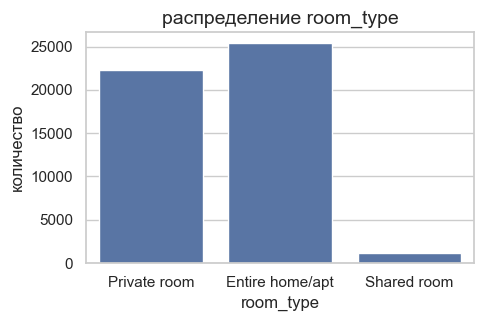

In [497]:
plt.figure(figsize=(5, 3))
sns.countplot(data=airbnb_dirty, x="room_type")

plt.title("распределение room_type", fontsize=14)
plt.xlabel("room_type", fontsize=12)
plt.ylabel("количество", fontsize=12)

plt.show()

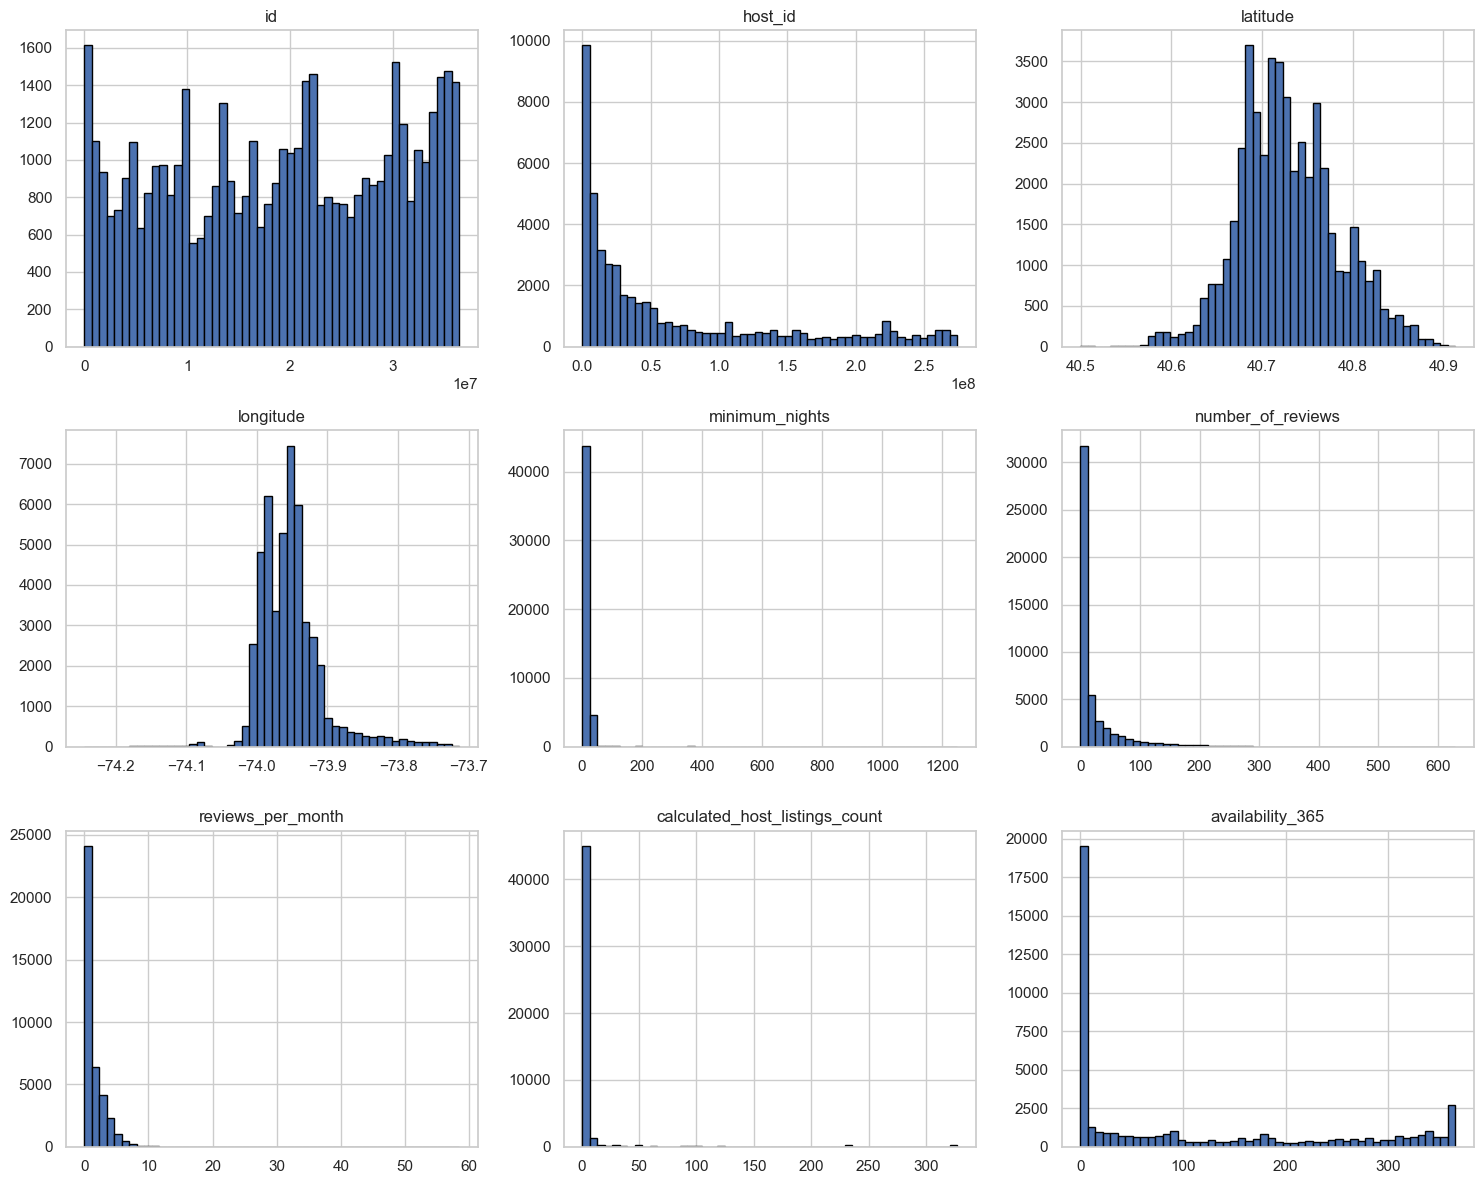

In [498]:
airbnb_dirty.hist(figsize=(15, 12), bins=50, edgecolor="black")

plt.tight_layout()
plt.show()

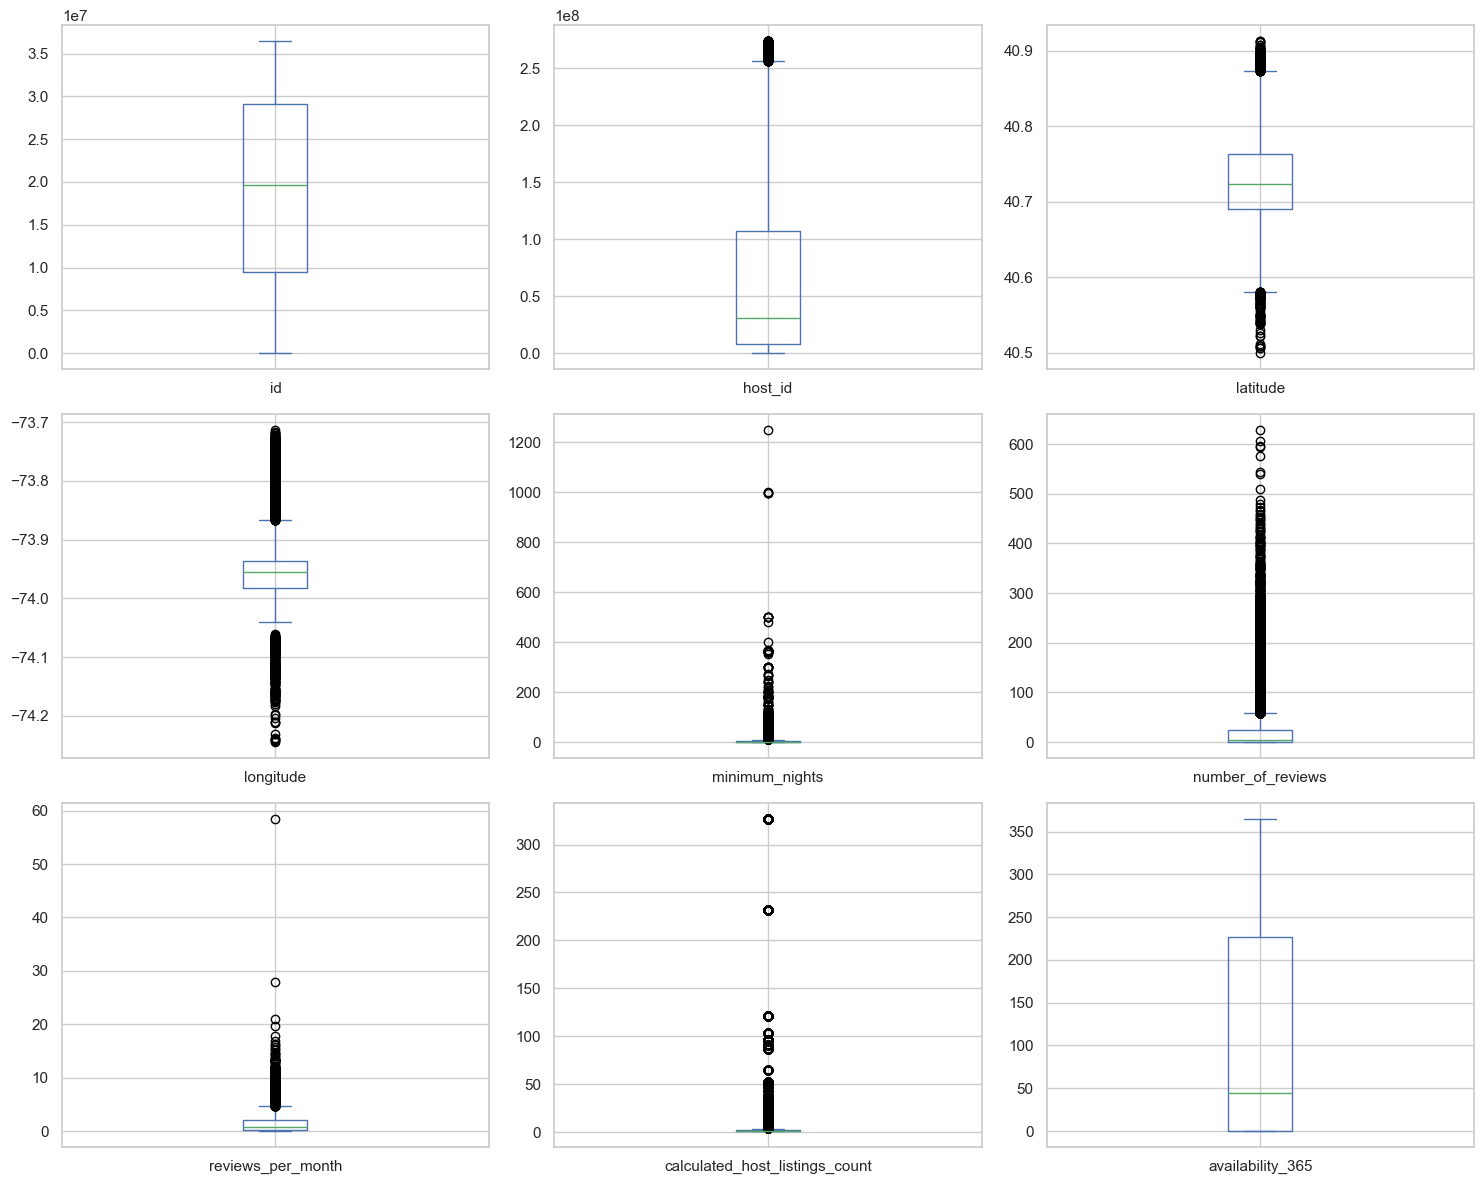

In [499]:
numeric_cols = airbnb_dirty.select_dtypes(include=["int64", "float64"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(3, 3), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

### После EDA сформулируйте план чистки

Не пишите код сразу. Сначала словами:

- что сделаем с `price`;
- что сделаем с `name`;
- что сделаем с пропусками;
- что сделаем с экстремальными `minimum_nights`;
- какие новые признаки можно извлечь.

In [500]:
airbnb_dirty[airbnb_dirty["id"] == 28958489]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
36409,28958489,Cosy room on the ocean beach.,93315723,Анита,Brooklyn,Brighton Beach,40.57795,-73.9616,Private room,50,2,27,2019-06-26,3.18,1,71


In [ ]:
cleaning_plan = {
    "price": "Нужно написать regex, который бы убирал usd, $ и применял strip на строку price",
    "name": "привести к нижнему регистру, оставить только английский алфавит и знаки препинания",
    "missing_values": "last_review заполняем never, reviews_per_month = 0 там, где last_review nan(мало ли где-то ошибка и last_review имеет какое-то значение, а reviews_per_month - нет), host_name(оказалось, там есть и русские имена) лучше поставить просто пустую строку, для надёжности приведём к нижнему регистру",
    "outliers": "заполнить выбросы minimum_nights значениями 365",
    "new_features": [
        "no_reviews/few_reviews",
        "small_S",
        "нужно посмотреть, влияет ли room_type на цену. скорее всего entire_home будет дороже в среднем, можно ввести признак is_entire_home",
        "one-hot encoding для neighbour_group"
    ],
}

cleaning_plan

{'price': 'Нужно написать regex, который бы убирал usd, $ и применял strip на строку price',
 'name': 'привести к нижнему регистру, оставить только английский алфавит и знаки препинания',
 'missing_values': 'last_review заполняем never, reviews_per_month = 0 там, где last_review nan(мало ли где-то ошибка и last_review имеет какое-то значение, а reviews_per_month - нет), host_name(оказалось, там есть и русские имена) лучше поставить просто пустую строку, для надёжности приведём к нижнему регистру',
 'outliers': 'заполнить выбросы minimum_nights значениями 365',
 'new_features': ['no_reviews/few_reviews',
  'small_S',
  'нужно посмотреть, влияет ли room_type на цену. скорее всего entire_home будет дороже в среднем, можно ввести признак is_entire_home']}

In [502]:
# TODO 4. Очистите данные.
# Идеи, которые можно использовать:
# 1. price -> превратить в float
# 2. name -> заполнить пропуски пустой строкой
# 3. reviews_per_month -> заполнить нулями
# 4. last_review_missing -> бинарный признак пропуска
# 5. minimum_nights_clipped -> ограничить сверху, например p99 или 45
# 6. minimum_nights_log -> взять log1p
# 7. name_len, caps_ratio, has_exclamation -> простые текстовые признаки
# 8. is_entire_home -> бинарная цель для логистической регрессии

# Заготовки функций, если хотите:
# def clean_price_series(series):
#     cleaned = series.astype(str).str.replace(r'[^0-9.]', '', regex=True)
#     cleaned = cleaned.replace('', np.nan)
#     return pd.to_numeric(cleaned, errors='coerce')
#
# def caps_ratio(text):
#     letters = [ch for ch in str(text) if ch.isalpha()]
#     if not letters:
#         return 0.0
#     return sum(ch.isupper() for ch in letters) / len(letters)

airbnb_imp = airbnb_dirty.copy()

In [ ]:
#     "new_features": [
#         "no_reviews/few_reviews",
#         "small_S",
#         "нужно посмотреть, влияет ли room_type на цену. скорее всего entire_home будет дороже в среднем, можно ввести признак is_entire_home",
#         "one-hot encoding для neighbour_group"
#     ]

In [503]:
airbnb_imp["price"] = (airbnb_imp["price"]
                       .astype(str)
                       .str.lower()
                       .str.replace('$', '')
                       .str.replace('usd', '')
                       .str.replace(',', '')
                       .str.strip()
                       .astype(float))

In [ ]:
airbnb_imp["host_name"] = airbnb_imp["host_name"].fillna("").astype(str).str.lower()


pattern_for_name = r"[^a-zа-я0-9\s\.\,\!\?\;\:\(\)\'\"\-\|]"
airbnb_imp["name"] = (airbnb_imp["name"]
                      .astype(str)
                      .str.lower()
                      .str.replace(pattern_for_name, '', regex=True)
                      .str.strip())


last_review_nan_equals_reviews_per_month_nan = airbnb_imp["last_review"][airbnb_imp["reviews_per_month"].isna()]

if len(last_review_nan_equals_reviews_per_month_nan) == 10052:
    print("hell yeah")
    airbnb_imp["last_review"] = airbnb_imp["last_review"].fillna("never")
    airbnb_imp["reviews_per_month"] = airbnb_imp["reviews_per_month"].fillna(0)


airbnb_imp["minimum_nights"] = airbnb_imp["minimum_nights"].clip(upper=365)

hell yeah


In [505]:
missing = airbnb_imp.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [506]:
airbnb_imp[
    ["host_name", "name", "price", "minimum_nights", "last_review", "reviews_per_month"]
].sample(8, random_state=42)

,host_name,name,price,minimum_nights,last_review,reviews_per_month
879,jane,come and go as you please in bkln!,89.0,3,2019-01-02,0.71
44383,giancarlo,"spacious, sunny room in queensbrooklyn",30.0,21,never,0.00
15394,alejandro,private bedroom in high-ceiling 4br apartment!,120.0,2,2017-04-28,0.43
43230,sonder (nyc),sonder | stock exchange | stunning 3br kitche...,470.0,2,2019-06-02,1.88
16332,gingie,spacious 2 bedroom with balcony!!!,199.0,2,2019-06-03,0.80
5966,amanda,entire 2br apt (not a railroad),170.0,1,2019-06-22,3.05
29838,hugo,1br in spacious 2 br in the heart of williamsb...,90.0,5,2018-02-21,0.06
41764,jing,comfortable place to live,60.0,30,never,0.00


## Блок 3. Линейная регрессия на Airbnb: цена

Теперь идем по той же логике, что и в основном ноуте.

### Что важно сделать честно

1. Сначала сравнить с `Mean baseline`.
2. Потом попробовать простую линейную регрессию.
3. Потом добавить feature engineering.
4. Если хочется углубиться, можно посчитать OLS руками через формулу из лекции.

In [507]:
regression_hypotheses = {
    "target": "price или price_capped",
    "baseline_features": ["", "", ""],
    "improved_features": ["", "", "", ""],
    "which_metric_is_most_important": "",
}

regression_hypotheses

{'target': 'price или price_capped',
 'baseline_features': ['', '', ''],
 'improved_features': ['', '', '', ''],
 'which_metric_is_most_important': ''}

In [ ]:
airbnb_imp["neighbourhood_group"].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [ ]:
# TODO 5. Сделайте baseline для регрессии.
# План:
# 1. выбрать target, например price_capped
# 2. сделать train/test split
# 3. сравнить Mean baseline и sklearn LinearRegression
# 4. посчитать R2, MAE, RMSE, NRMSE, MAPE_%

# Подсказка:
# y_mean_pred = np.repeat(y_train.mean(), len(y_test))
# regression_metrics(y_test, y_mean_pred)
# regression_metrics(y_test, model.predict(X_test))

cols_to_drop = ['id', 'name', 'host_id', 'host_name', 'last_review', 'price', 'neighbourhood']
X = airbnb_imp.drop(columns=cols_to_drop)
print(X)
y = airbnb_imp['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# mean baseline
y_mean_pred = np.repeat(y_train.mean(), len(y_test))
print('mean baseline:', regression_metrics(y_test, y_mean_pred))

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('LinearRegression:', regression_metrics(y_test, model.predict(X_test)))

      neighbourhood_group  latitude  longitude        room_type  \
0                Brooklyn  40.64749  -73.97237     Private room   
1               Manhattan  40.75362  -73.98377  Entire home/apt   
2               Manhattan  40.80902  -73.94190     Private room   
3                Brooklyn  40.68514  -73.95976  Entire home/apt   
4               Manhattan  40.79851  -73.94399  Entire home/apt   
...                   ...       ...        ...              ...   
48890            Brooklyn  40.67853  -73.94995     Private room   
48891            Brooklyn  40.70184  -73.93317     Private room   
48892           Manhattan  40.81475  -73.94867  Entire home/apt   
48893           Manhattan  40.75751  -73.99112      Shared room   
48894           Manhattan  40.76404  -73.98933     Private room   

       minimum_nights  number_of_reviews  reviews_per_month  \
0                   1                  9               0.21   
1                   1                 45               0.38   
2     

ValueError: could not convert string to float: 'Queens'

In [509]:
# TODO 6. Добавьте feature engineering и сравните качество.
# Идеи признаков:
# - neighbourhood_group
# - room_type
# - latitude, longitude
# - minimum_nights_clipped, minimum_nights_log
# - name_len, caps_ratio, has_exclamation
# - last_review_missing

# Подсказка:
# X_improved = pd.get_dummies(..., drop_first=True)

# Ваш код здесь

In [510]:
# TODO 7. Если хотите пойти глубже, реализуйте ручной OLS.
# Это прямое продолжение формулы из лекции:
# w* = (X^T X)^(-1) X^T y
#
# Подсказка:
# weights = manual_linear_weights(X_train, y_train)
# y_pred_manual = manual_linear_predict(X_test, weights)
# regression_metrics(y_test, y_pred_manual)
#
# Важно:
# - перед этим X должен быть только числовой
# - лучше сравнить ручной результат со sklearn на одной и той же матрице признаков

# Ваш код здесь

### Вопросы после регрессии

- Почему `R2` может быть скромным, а модель всё равно полезнее mean baseline?
- Чем `MAE` отличается от `RMSE` по смыслу?
- Почему `RMSE` особенно чувствительна к редким большим ошибкам?
- Почему на Airbnb вообще не стоит ждать идеально высокой линейной метрики?

## Блок 4. Классификация на Airbnb: тип жилья

Теперь меняем задачу.

### Бинарная цель

- `1` = `Entire home/apt`
- `0` = `Private room`

### Что важно сделать

1. Сравнить с majority baseline.
2. Проверить `LinearRegression + clip` как плохой классификатор.
3. Обучить `LogisticRegression`.
4. Если хочется углубиться, сделать ручную логистическую регрессию через сигмоиду.

In [511]:
classification_hypotheses = {
    "target": "is_entire_home",
    "useful_features": ["", "", "", ""],
    "why_logistic_is_more_natural": "",
    "which_metric_is_most_important": "",
}

classification_hypotheses

{'target': 'is_entire_home',
 'useful_features': ['', '', '', ''],
 'why_logistic_is_more_natural': '',
 'which_metric_is_most_important': ''}

In [512]:
# TODO 8. Сделайте baseline для классификации.
# Шаги:
# 1. оставьте только Entire home/apt и Private room
# 2. соберите признаки
# 3. сделайте majority baseline
# 4. посчитайте Accuracy, Precision, Recall, F1, ROC_AUC, LogLoss

# Подсказка:
# majority_class = int(y_train.mean() >= 0.5)
# majority_prob = np.repeat(float(y_train.mean()), len(y_test))
# majority_pred = np.repeat(majority_class, len(y_test))
# classification_metrics(y_test, majority_prob, majority_pred)

# Ваш код здесь

In [513]:
# TODO 9. Сравните LinearRegression + clip и LogisticRegression.
# Подсказка:
# 1. для LinearRegression получите сырые scores
# 2. потом prob = np.clip(scores, 0, 1)
# 3. pred = (prob >= 0.5).astype(int)
# 4. для LogisticRegression используйте predict_proba
# 5. сравните метрики не только между собой, но и с majority baseline

# Ваш код здесь

In [514]:
# TODO 10. Если хотите пойти глубже, реализуйте ручную логистическую регрессию.
# Это прямое продолжение лекции:
# p(x) = sigmoid(w^T x)
# log-loss = -mean(y log p + (1-y) log(1-p))
#
# Подсказка:
# 1. возьмите маленький набор числовых признаков
# 2. стандартизируйте train/test
# 3. weights, history = fit_logistic_manual(X_train_std, y_train, lr=0.2, steps=1200)
# 4. prob = predict_logistic_manual(X_test_std, weights)
# 5. pred = (prob >= 0.5).astype(int)
# 6. classification_metrics(y_test, prob, pred)

# Ваш код здесь

### Вопросы после классификации

- Почему `Accuracy` не всегда достаточно?
- Когда важнее `Precision`, а когда `Recall`?
- Почему `LogLoss` может быть содержательнее, чем просто доля угаданных классов?
- Если `LinearRegression + clip` не сильно хуже по `Accuracy`, почему мы всё равно говорим, что логистическая регрессия здесь естественнее?

## Блок 5. Свои идеи

Теперь можно предлагать собственные улучшения.

Хорошие направления:

- взять `log(price)` вместо `price_capped`;
- попробовать новые текстовые признаки;
- сильнее ограничить выбросы;
- оставить только крупные районы;
- попробовать другие наборы признаков для ручной логистической регрессии;
- сравнивать новые идеи не только с лучшей моделью, но и с baseline.

In [515]:
student_experiment = {
    "idea": "",
    "why_it_should_help": "",
    "which_metric_should_improve": "",
    "result": "",
}

student_experiment

{'idea': '',
 'why_it_should_help': '',
 'which_metric_should_improve': '',
 'result': ''}

In [516]:
# TODO 11. Песочница для вашей идеи.
# Совет:
# 1. сначала напишите гипотезу словами выше
# 2. потом укажите, по какой метрике ждете улучшение
# 3. только потом пишите код

# Ваш код здесь

## Финальная рефлексия

Заполните коротко, но честно. Это важнее, чем просто много кода.

In [517]:
final_reflection = {
    "what_helped_in_eda_the_most": "",
    "which_regression_metric_was_most_informative": "",
    "which_classification_metric_was_most_informative": "",
    "where_linear_regression_was_natural": "",
    "why_logistic_regression_was_more_natural_for_binary_target": "",
    "which_formula_from_the_lecture_became_clearer_after_code": "",
}

final_reflection

{'what_helped_in_eda_the_most': '',
 'which_regression_metric_was_most_informative': '',
 'which_classification_metric_was_most_informative': '',
 'where_linear_regression_was_natural': '',
 'why_logistic_regression_was_more_natural_for_binary_target': '',
 'which_formula_from_the_lecture_became_clearer_after_code': ''}